# Rental Pricing Dataset, Malaysia

Dataset Link: https://www.kaggle.com/datasets/ariewijaya/rent-pricing-kuala-lumpur-malaysi

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv("mudah-apartment-kl-selangor.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ads_id                 19991 non-null  int64  
 1   prop_name              19043 non-null  object 
 2   completion_year        10806 non-null  float64
 3   monthly_rent           19989 non-null  object 
 4   location               19991 non-null  object 
 5   property_type          19991 non-null  object 
 6   rooms                  19985 non-null  object 
 7   parking                14289 non-null  float64
 8   bathroom               19985 non-null  float64
 9   size                   19991 non-null  object 
 10  furnished              19986 non-null  object 
 11  facilities             17782 non-null  object 
 12  additional_facilities  14043 non-null  object 
 13  region                 19991 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 2.1+

In [4]:
df.head()

,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,region
0,100323185,The Hipster @ Taman Desa,2022.0,RM 4 200 per month,Kuala Lumpur - Taman Desa,Condominium,5,2.0,6.0,1842 sq.ft.,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swimming Pool, Parking, Lift, Barbeque area, Multipurpose hall, Jogging Track","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur
1,100203973,Segar Courts,NaN,RM 2 300 per month,Kuala Lumpur - Cheras,Condominium,3,1.0,2.0,1170 sq.ft.,Partially Furnished,"Playground, Parking, Barbeque area, Security, Jogging Track, Swimming Pool, Gymnasium, Lift, Sauna","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur
2,100323128,Pangsapuri Teratak Muhibbah 2,NaN,RM 1 000 per month,Kuala Lumpur - Taman Desa,Apartment,3,NaN,2.0,650 sq.ft.,Fully Furnished,"Minimart, Jogging Track, Lift, Swimming Pool",NaN,Kuala Lumpur
3,100191767,Sentul Point Suite Apartment,2020.0,RM 1 700 per month,Kuala Lumpur - Sentul,Apartment,2,1.0,2.0,743 sq.ft.,Partially Furnished,"Parking, Playground, Swimming Pool, Squash Court, Security, Minimart, Gymnasium, Lift","Cooking Allowed, Near KTM/LRT, Washing Machine",Kuala Lumpur
4,97022692,Arte Mont Kiara,NaN,RM 1 299 per month,Kuala Lumpur - Mont Kiara,Service Residence,1,1.0,1.0,494 sq.ft.,Not Furnished,"Parking, Security, Lift, Swimming Pool, Playground, Gymnasium, Barbeque area, Minimart, Multipurpose hall, Club house, Jogging Track",Air-Cond,Kuala Lumpur


## Data Cleaning

In [5]:
df = df.drop(columns=["ads_id"], axis=1)

In [6]:
# Strip text from the rental price
df['monthly_rent'] = (
    df['monthly_rent']
    .str.replace('RM', '', regex=False)
    .str.replace('per month', '', regex=False)
    .str.replace(' ', '', regex=False)
)

df['monthly_rent'] = pd.to_numeric(df['monthly_rent'], errors='coerce')

In [7]:
# Fill missing parking counts with 1 if facilities mention parking
mask = (
    df['parking'].isna() &
    df['facilities'].str.lower().str.contains('parking', na=False)
)

df.loc[mask, 'parking'] = 1
print(f'Total rows filled with 1 for parking field {mask.sum()}')
print(f'Parking with NULL Values {df['parking'].isna().sum()}')

Total rows filled with 1 for parking field 3754
Parking with NULL Values 1948


In [8]:
# Drop the 'Kuala Lumput -' from the location field
df['location'] = df['location'].str.replace(r'^(Kuala Lumpur|Selangor)\s*-\s*', '', regex=True)
print(df['location'].nunique())

129


In [9]:
# Drop the sq.ft. from size
df["size"] = df["size"].str.extract(r"(\d+)").astype(int)

In [10]:
# Encode furnished into one-hot encodings
df["fully_furnished"] = (
    df["furnished"]
    .str.strip()
    .str.lower()
    .eq("fully furnished")
    .astype(int)
)
df = df.drop(columns=["furnished"])

In [11]:
# Convert year information into age
# 2023 is used as the dataset was scrapped in that year
current_year = 2023
df["property_age"] = current_year - df["completion_year"]
df = df.drop(columns=["completion_year"], axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prop_name              19043 non-null  object 
 1   monthly_rent           19989 non-null  float64
 2   location               19991 non-null  object 
 3   property_type          19991 non-null  object 
 4   rooms                  19985 non-null  object 
 5   parking                18043 non-null  float64
 6   bathroom               19985 non-null  float64
 7   size                   19991 non-null  int64  
 8   facilities             17782 non-null  object 
 9   additional_facilities  14043 non-null  object 
 10  region                 19991 non-null  object 
 11  fully_furnished        19991 non-null  int64  
 12  property_age           10806 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [13]:
# Map region data into one-hot encodings 
df = pd.get_dummies(df, columns=["region"], dtype=int)


In [14]:
# Convert facilities data into one hot encodings
facilities_one_hot = df["facilities"].str.get_dummies(sep=", ")
facilities_one_hot = facilities_one_hot.drop(columns=["10", "11", "6"], axis=1)

additional_facilities_one_hot = df["additional_facilities"].str.get_dummies(sep=", ")

df = df.join(facilities_one_hot)
df = df.join(additional_facilities_one_hot)
df = df.drop(columns=["facilities", "additional_facilities"], axis=1)


In [15]:
# Remove anomalies of rental greater than RM18500 per month
num_removed = (df['monthly_rent'] > 18500).sum()
print(f"Rows to remove: {num_removed}")
df = df[df['monthly_rent'] <= 18500]

# Remove anomalies of rental less than RM300 per month
num_removed = (df['monthly_rent'] < 300).sum()
print(f"Rows to remove: {num_removed}")
df = df[df['monthly_rent'] >= 300]

Rows to remove: 35
Rows to remove: 51


In [16]:
df[['parking', 'rooms', 'bathroom']] = df[['parking', 'rooms' , 'bathroom']].fillna(0)

In [17]:
df['age_missing'] = df['property_age'].isna().astype(int)

df['property_age'] = df['property_age'].fillna(
    df['property_age'].median()
)

In [18]:
# Group Rare Categories of houses
# print(df['location'].unique())
# print(df['property_type'].unique())
# df['property_type'].value_counts()

rare_types = [
    'Others',
    'Duplex',
    'Townhouse Condo',
    'Houses'
]

df['property_type'] = df['property_type'].replace(
    rare_types,
    'Other'
)

In [19]:
null_row_count = df.isna().any(axis=1).sum()

print(f"Rows with nulls: {null_row_count}")

Rows with nulls: 936


In [20]:
# Convert rooms to numerical numbers and removing abnormal data with strong
df = df[df['rooms'] != 'More than 10']
df['rooms'] = pd.to_numeric(df['rooms'])

In [21]:
df.isna().sum().sort_values(ascending=False)

prop_name              935
monthly_rent             0
location                 0
property_type            0
rooms                    0
parking                  0
bathroom                 0
size                     0
fully_furnished          0
property_age             0
region_Kuala Lumpur      0
region_Selangor          0
Barbeque area            0
Club house               0
Gymnasium                0
Jogging Track            0
Lift                     0
Minimart                 0
Multipurpose hall        0
Parking                  0
Playground               0
Sauna                    0
Security                 0
Squash Court             0
Swimming Pool            0
Tennis Court             0
Air-Cond                 0
Cooking Allowed          0
Internet                 0
Near KTM/LRT             0
Washing Machine          0
age_missing              0
dtype: int64

## Exploratory Data Analysis

/tmp/ipykernel_19246/468961189.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(


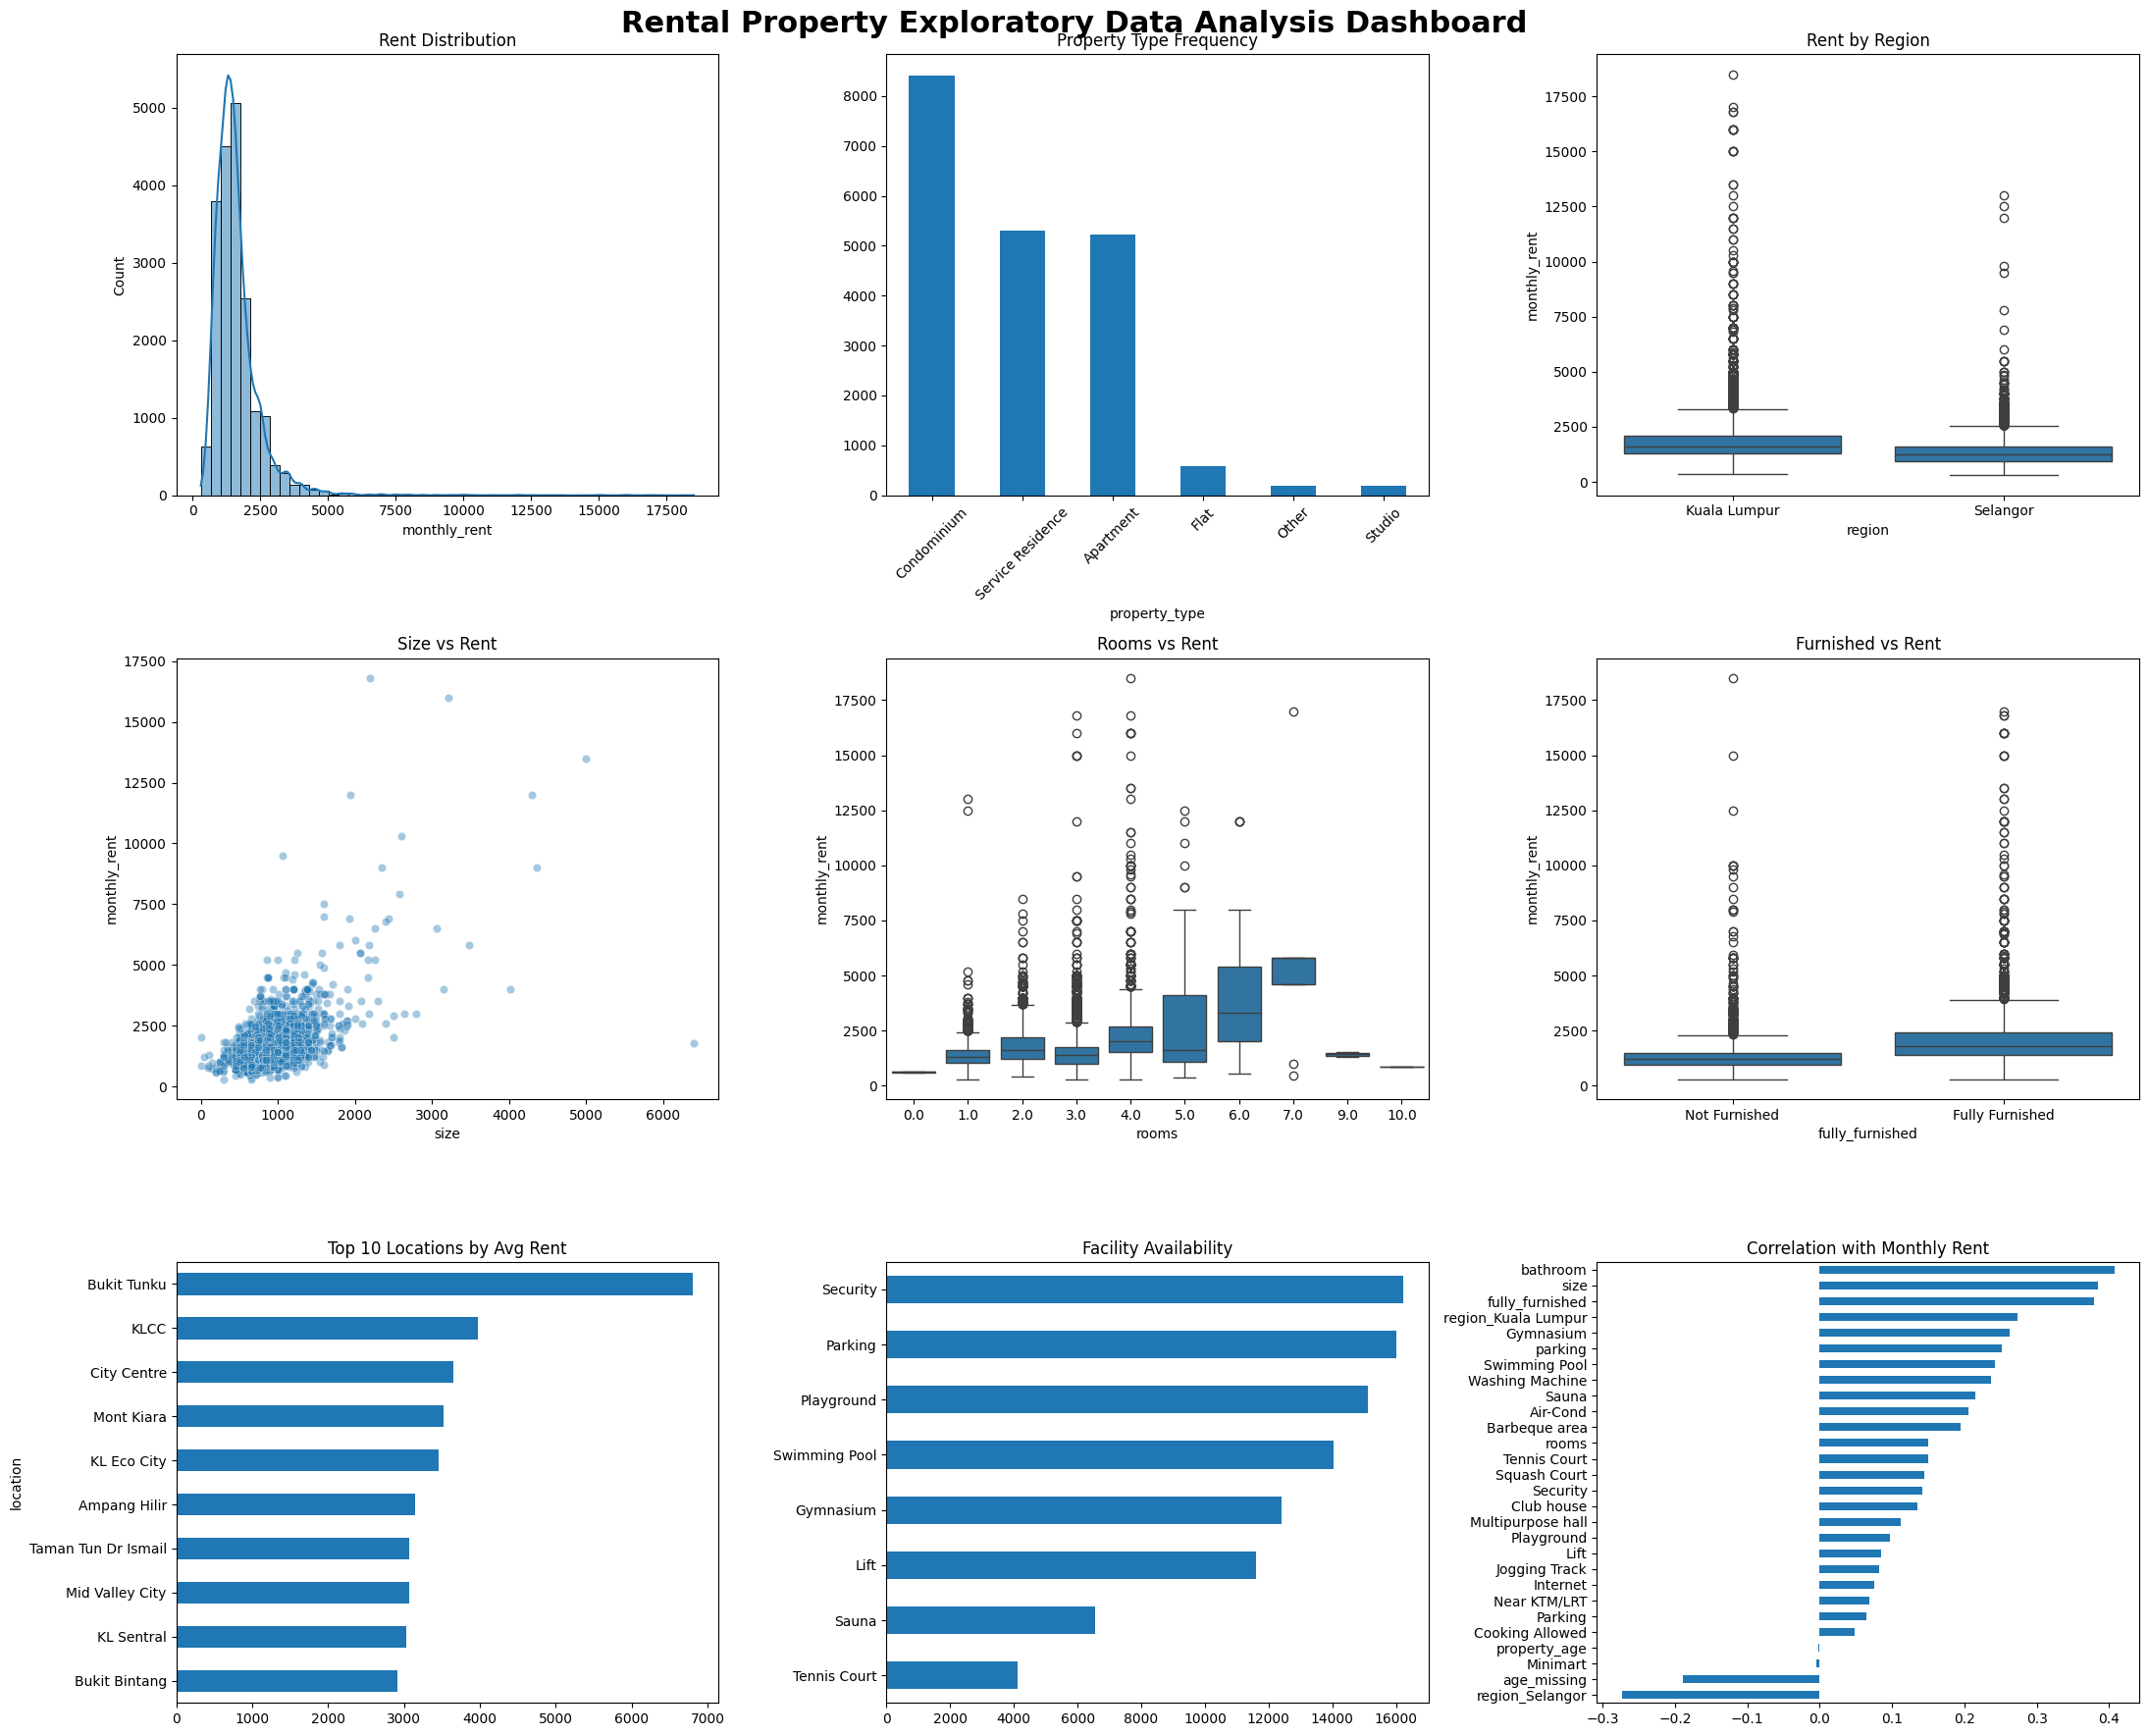

In [22]:
# Region column
df['region'] = np.where(
    df['region_Kuala Lumpur']==1,
    'Kuala Lumpur',
    'Selangor'
)

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Rental Property Exploratory Data Analysis Dashboard',
             fontsize=22,
             fontweight='bold')

# -------------------------------------------------
# 1. Rent Distribution
# -------------------------------------------------
sns.histplot(df['monthly_rent'],
             bins=50,
             kde=True,
             ax=axes[0,0])

axes[0,0].set_title('Rent Distribution')

# -------------------------------------------------
# 2. Property Type Count
# -------------------------------------------------
df['property_type'].value_counts().plot(
    kind='bar',
    ax=axes[0,1]
)

axes[0,1].set_title('Property Type Frequency')
axes[0,1].tick_params(axis='x', rotation=45)

# -------------------------------------------------
# 3. Region Comparison
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='region',
    y='monthly_rent',
    ax=axes[0,2]
)

axes[0,2].set_title('Rent by Region')

# -------------------------------------------------
# 4. Size vs Rent
# -------------------------------------------------
sns.scatterplot(
    data=df.sample(min(3000, len(df))),
    x='size',
    y='monthly_rent',
    alpha=0.4,
    ax=axes[1,0]
)

axes[1,0].set_title('Size vs Rent')

# -------------------------------------------------
# 5. Rooms vs Rent
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='rooms',
    y='monthly_rent',
    ax=axes[1,1]
)

axes[1,1].set_title('Rooms vs Rent')

# -------------------------------------------------
# 6. Furnished vs Rent
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='fully_furnished',
    y='monthly_rent',
    ax=axes[1,2]
)

axes[1,2].set_title('Furnished vs Rent')
axes[1,2].set_xticklabels(
    ['Not Furnished','Fully Furnished']
)

# -------------------------------------------------
# 7. Top Locations
# -------------------------------------------------
top_loc = (
    df.groupby('location')['monthly_rent']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_loc.sort_values().plot(
    kind='barh',
    ax=axes[2,0]
)

axes[2,0].set_title('Top 10 Locations by Avg Rent')

# -------------------------------------------------
# 8. Common Facilities
# -------------------------------------------------
facilities = [
    'Swimming Pool',
    'Gymnasium',
    'Security',
    'Parking',
    'Playground',
    'Lift',
    'Sauna',
    'Tennis Court'
]

df[facilities].sum().sort_values().plot(
    kind='barh',
    ax=axes[2,1]
)

axes[2,1].set_title('Facility Availability')

# -------------------------------------------------
# 9. Correlation with Rent
# -------------------------------------------------
corr = (
    df.select_dtypes(include=['int64','float64'])
      .corr()['monthly_rent']
      .sort_values()
)

corr.drop('monthly_rent').plot(
    kind='barh',
    ax=axes[2,2]
)

axes[2,2].set_title('Correlation with Monthly Rent')

plt.tight_layout()
plt.show()
df = df.drop(columns=["region"], axis=1)

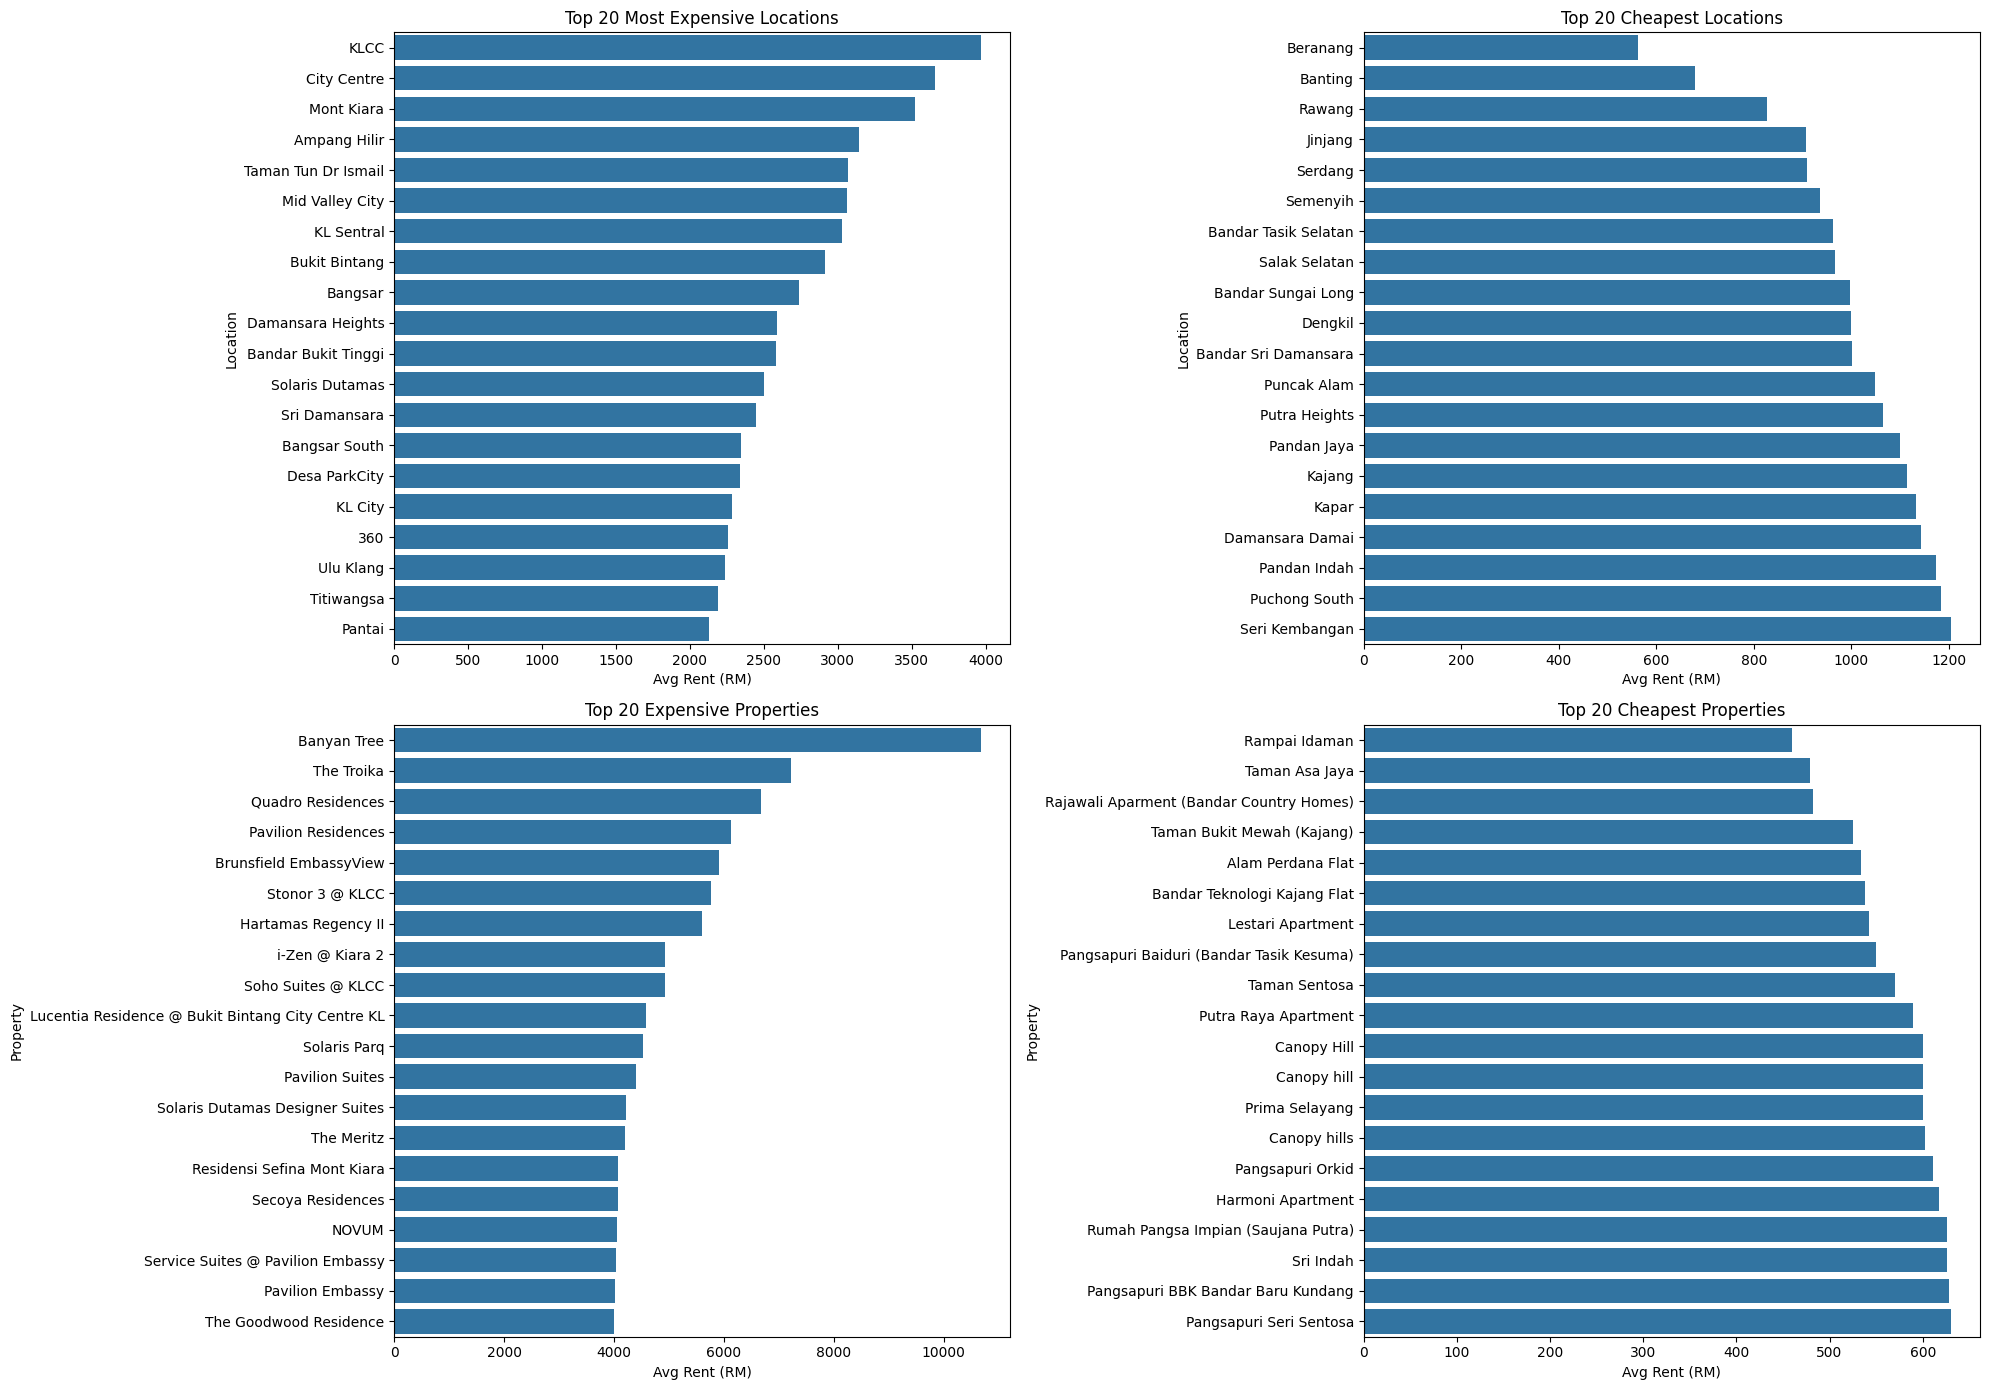

In [23]:
location_stats = (
    df.groupby('location')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# -------------------------
# 1. Top expensive locations
# -------------------------
top_loc = location_stats.sort_values('mean', ascending=False).head(20)

sns.barplot(
    data=top_loc.reset_index(),
    x='mean',
    y='location',
    ax=axes[0,0]
)
axes[0,0].set_title('Top 20 Most Expensive Locations')
axes[0,0].set_xlabel('Avg Rent (RM)')
axes[0,0].set_ylabel('Location')

# -------------------------
# 2. Cheapest locations
# -------------------------
bottom_loc = location_stats.sort_values('mean', ascending=True).head(20)

sns.barplot(
    data=bottom_loc.reset_index(),
    x='mean',
    y='location',
    ax=axes[0,1]
)
axes[0,1].set_title('Top 20 Cheapest Locations')
axes[0,1].set_xlabel('Avg Rent (RM)')
axes[0,1].set_ylabel('Location')

# -------------------------
# 3. Expensive properties
# -------------------------
top_prop = (
    df.groupby('prop_name')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
      .sort_values('mean', ascending=False)
      .head(20)
)

sns.barplot(
    data=top_prop.reset_index(),
    x='mean',
    y='prop_name',
    ax=axes[1,0]
)
axes[1,0].set_title('Top 20 Expensive Properties')
axes[1,0].set_xlabel('Avg Rent (RM)')
axes[1,0].set_ylabel('Property')

# -------------------------
# 4. Cheapest properties
# -------------------------
bottom_prop = (
    df.groupby('prop_name')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
      .sort_values('mean', ascending=True)
      .head(20)
)

sns.barplot(
    data=bottom_prop.reset_index(),
    x='mean',
    y='prop_name',
    ax=axes[1,1]
)
axes[1,1].set_title('Top 20 Cheapest Properties')
axes[1,1].set_xlabel('Avg Rent (RM)')
axes[1,1].set_ylabel('Property')

plt.tight_layout()
plt.show()

## Feature Selection and Data Encoding

In [24]:
# Remove property name from the dataframe
df_property_name = df.pop('prop_name').to_frame()

# Remoce duplicate Parking column
df = df.drop(columns=['Parking'])

In [25]:
# Group facilities columns together
df['basic_facilities'] = (
    df['Lift'] +
    df['Air-Cond'] +
    df['Washing Machine'] +
    df['Internet'] +
    df['Cooking Allowed']
)

df['building_facilities'] = (
    df['Gymnasium'] +
    df['Swimming Pool'] +
    df['Security'] +
    df['Playground'] +
    df['Jogging Track'] +
    df['Multipurpose hall']
)

df['luxury_facilities'] = (
    df['Squash Court'] +
    df['Tennis Court'] +
    df['Sauna'] +
    df['Club house'] +
    df['Barbeque area']
)

facility_cols = [
    'Barbeque area', 'Club house', 'Gymnasium', 'Jogging Track',
    'Lift', 'Minimart', 'Multipurpose hall',
    'Playground', 'Sauna', 'Security', 'Squash Court',
    'Swimming Pool', 'Tennis Court', 'Air-Cond',
    'Cooking Allowed', 'Internet', 'Near KTM/LRT', 'Washing Machine'
]

df = df.drop(columns=facility_cols)


In [26]:
df.head()

,monthly_rent,location,property_type,rooms,parking,bathroom,size,fully_furnished,property_age,region_Kuala Lumpur,region_Selangor,age_missing,basic_facilities,building_facilities,luxury_facilities
0,4200.0,Taman Desa,Condominium,5.0,2.0,6.0,1842,1,1.0,1,0,0,4,6,1
1,2300.0,Cheras,Condominium,3.0,1.0,2.0,1170,0,6.0,1,0,1,3,5,2
2,1000.0,Taman Desa,Apartment,3.0,0.0,2.0,650,1,6.0,1,0,1,1,2,0
3,1700.0,Sentul,Apartment,2.0,1.0,2.0,743,0,3.0,1,0,0,3,4,1
4,1299.0,Mont Kiara,Service Residence,1.0,1.0,1.0,494,0,6.0,1,0,1,2,6,2


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19901 entries, 0 to 19990
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   monthly_rent         19901 non-null  float64
 1   location             19901 non-null  object 
 2   property_type        19901 non-null  object 
 3   rooms                19901 non-null  float64
 4   parking              19901 non-null  float64
 5   bathroom             19901 non-null  float64
 6   size                 19901 non-null  int64  
 7   fully_furnished      19901 non-null  int64  
 8   property_age         19901 non-null  float64
 9   region_Kuala Lumpur  19901 non-null  int64  
 10  region_Selangor      19901 non-null  int64  
 11  age_missing          19901 non-null  int64  
 12  basic_facilities     19901 non-null  int64  
 13  building_facilities  19901 non-null  int64  
 14  luxury_facilities    19901 non-null  int64  
dtypes: float64(5), int64(8), object(2)
memory

## Machine Learning

In [28]:
# Function for one_hot_encoding 
def one_hot_encode (df_in):
    _df = df_in.copy()
    _df = pd.get_dummies(_df, columns=['property_type'], drop_first=True)
    _df = pd.get_dummies(_df, columns=['location'], drop_first=True)
    return _df

### Linear Regression

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['monthly_rent'])
y = df['monthly_rent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ['rooms', 'parking', 'bathroom', 'size', 'property_age']

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X_train_lr = one_hot_encode(X_train)
X_test_lr = one_hot_encode(X_test)

# align columns (important!)
X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

# Scale with standardscaler
scaler = StandardScaler()
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols] = scaler.transform(X_test_lr[num_cols])

In [31]:
lr = LinearRegression()
lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)

## Random Forest Regressor

In [32]:
X_train_rf = one_hot_encode(X_train)
X_test_rf = one_hot_encode(X_test)

X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train)

y_pred_rf = rf.predict(X_test_rf)

### Gradient Boosting Regressor

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_rf, y_train)

y_pred_gbr = gbr.predict(X_test_rf)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.4f}")
    print("-"*30)

In [35]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gbr, "Gradient Boosting")

Linear Regression
MAE: 354.98
RMSE: 697.63
R2: 0.5286
------------------------------
Random Forest
MAE: 211.59
RMSE: 547.89
R2: 0.7092
------------------------------
Gradient Boosting
MAE: 292.74
RMSE: 593.22
R2: 0.6591
------------------------------


In [36]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf
})

results.head(50)

,Actual,Predicted
0,1600.0,1521.495000
1,1100.0,1322.411706
2,1600.0,1661.063889
3,900.0,756.241667
4,1400.0,1360.933333
5,1300.0,1302.500000
6,1800.0,1652.748750
7,3000.0,3412.890303
8,1500.0,1507.370000
9,2000.0,1664.253750


In [37]:
results['Error'] = results['Actual'] - results['Predicted']
results['Abs_Error'] = results['Error'].abs()

results.head(10)

,Actual,Predicted,Error,Abs_Error
0,1600.0,1521.495000,78.505000,78.505000
1,1100.0,1322.411706,-222.411706,222.411706
2,1600.0,1661.063889,-61.063889,61.063889
3,900.0,756.241667,143.758333,143.758333
4,1400.0,1360.933333,39.066667,39.066667
5,1300.0,1302.500000,-2.500000,2.500000
6,1800.0,1652.748750,147.251250,147.251250
7,3000.0,3412.890303,-412.890303,412.890303
8,1500.0,1507.370000,-7.370000,7.370000
9,2000.0,1664.253750,335.746250,335.746250
